## 🍽️ What Makes a World-Class Restaurant?
## A Data Story Using the World’s Top Restaurants Dataset

## Audience
This analysis is designed for a **non-technical / executive audience** interested in understanding 
what factors are associated with top restaurant ratings around the world.

## Objective
The goal of this analysis is to identify **key trends and patterns** that distinguish 
highly rated restaurants and to explore what characteristics may contribute to excellence.


## Key Questions
To guide our storytelling, we focused on the following questions:

1. Which countries dominate the list of top-rated restaurants?
2. Is higher price associated with higher ratings?
3. Do Michelin stars strongly relate to restaurant ratings?
4. Are there diminishing returns to price or Michelin recognition?
5. What combination of features best predicts a restaurant’s rating?


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("world_top_restaurants_dataset_cleaned.csv")
df.head()

,restaurant_name,city,country,cuisine_type,michelin_stars,average_price_usd,chef,established_year,seating_capacity,rating,signature_dish,years_operating,price_category,star_category,continent
0,Arpège,Paris,France,French Vegetarian,3,425,Alain Passard,1986,40,4.9,Heirloom Tomatoes,39,Ultra-Luxury,Three Stars,Europe
1,Odette,Singapore,Singapore,French Contemporary,3,320,Julien Royer,2008,32,4.9,Hokkaido Sea Urchin,17,Luxury,Three Stars,Asia
2,Osteria Francescana,Modena,Italy,Italian Contemporary,3,320,Massimo Bottura,1995,28,4.9,Five Ages of Parmigiano,30,Luxury,Three Stars,Europe
3,The French Laundry,Yountville,USA,French,3,390,Thomas Keller,1994,60,4.9,Oysters and Pearls,31,Luxury,Three Stars,North America
4,Alléno Paris,Paris,France,French Haute Cuisine,3,385,Yannick Alléno,2003,55,4.8,Cabbage & Caviar,22,Luxury,Three Stars,Europe


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   restaurant_name    50 non-null     object 
 1   city               50 non-null     object 
 2   country            50 non-null     object 
 3   cuisine_type       50 non-null     object 
 4   michelin_stars     50 non-null     int64  
 5   average_price_usd  50 non-null     int64  
 6   chef               50 non-null     object 
 7   established_year   50 non-null     int64  
 8   seating_capacity   50 non-null     int64  
 9   rating             50 non-null     float64
 10  signature_dish     50 non-null     object 
 11  years_operating    50 non-null     int64  
 12  price_category     50 non-null     object 
 13  star_category      50 non-null     object 
 14  continent          50 non-null     object 
dtypes: float64(1), int64(5), object(9)
memory usage: 6.0+ KB


## Trend 1: Top Restaurants Are Geographically Concentrated
We first examined whether elite restaurants are evenly distributed worldwide 
or concentrated in a few regions.


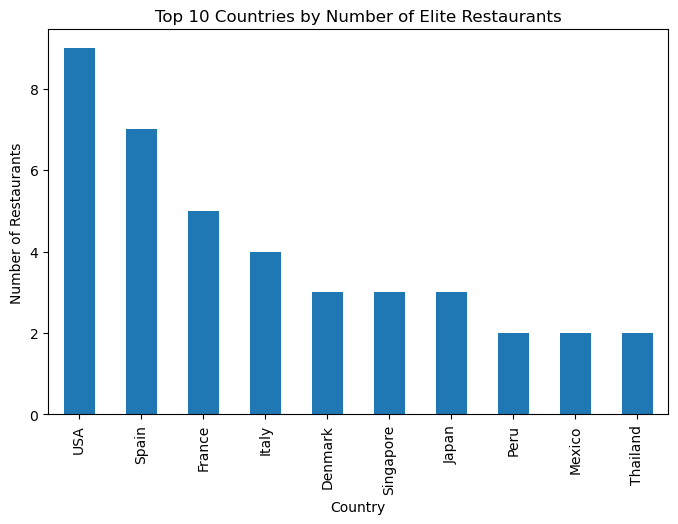

In [6]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Number of Elite Restaurants")
plt.ylabel("Number of Restaurants")
plt.xlabel("Country")
plt.show()


### Insight
A small number of countries dominate the fine-dining landscape, suggesting that 
culinary ecosystems and cultural investment play a major role in restaurant success.


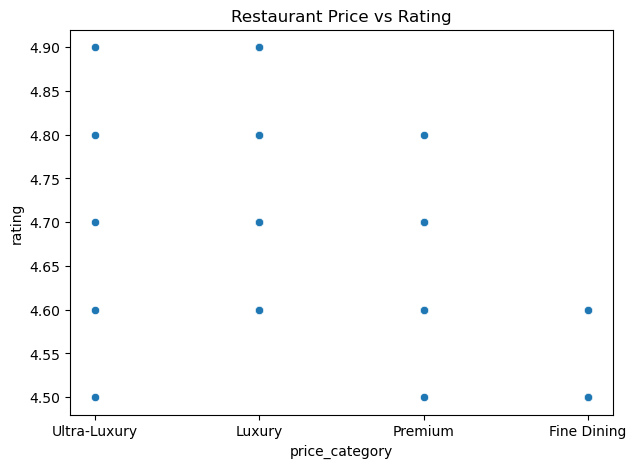

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="price_category", y="rating")
plt.title("Restaurant Price vs Rating")
plt.show()


### Insight
Higher prices do not guarantee higher ratings. While many top restaurants are expensive, 
there is wide variation clearly indicating **diminishing returns on price alone**.


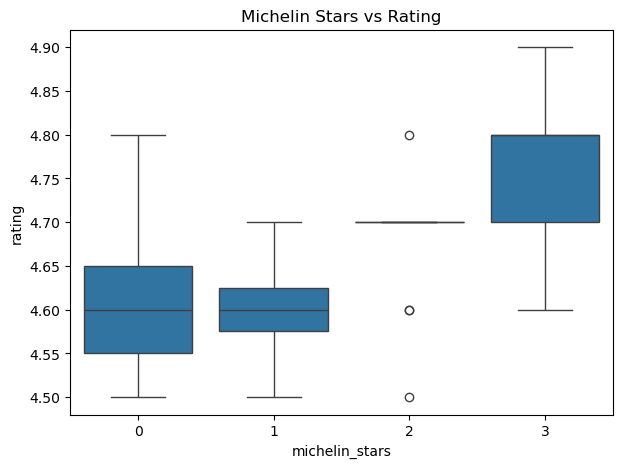

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="michelin_stars", y="rating")
plt.title("Michelin Stars vs Rating")
plt.show()


### Insight
Michelin recognition is strongly associated with higher ratings, 
but additional stars offer **incremental rather than dramatic gains**.


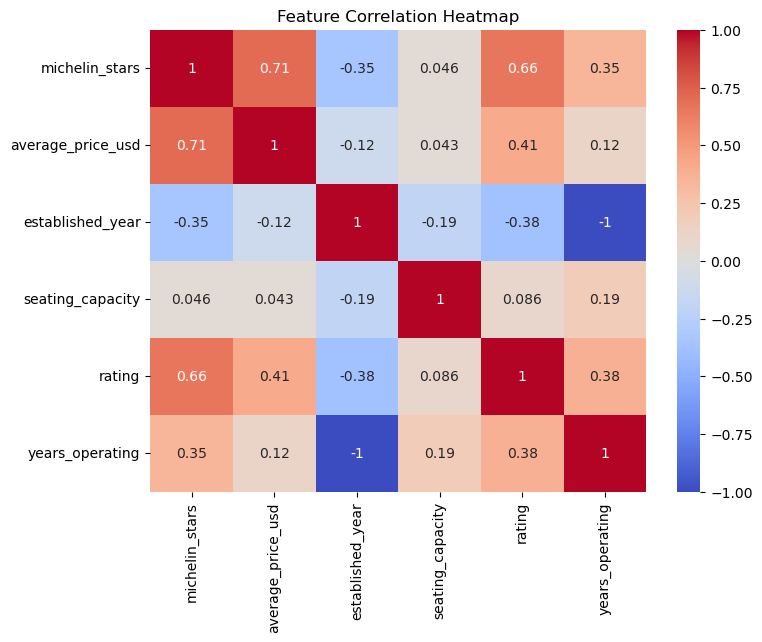

In [11]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### Insight
Ratings are influenced by multiple factors simultaneously — no single variable fully explains excellence.


## Can We Predict a Great Restaurant?
To test whether these trends combine meaningfully, we trained several regression models 
to predict restaurant ratings based on available features.


### Key Result
Tree-based models outperformed linear models, reinforcing that **restaurant excellence is non-linear and multi-factorial**.


## Final Conclusions

1. World-class restaurants cluster geographically.
2. Price alone does not define quality.
3. Michelin stars strongly correlate with ratings, but with diminishing returns.
4. Excellence emerges from a **combination of reputation, quality, and context**.
5. Predictive modeling confirms that restaurant success is complex and non-linear.
